<div style="text-align: center;">

# Image Preprocessing Basics

</div>

**Author:** Dr. Amir Omidvarnia  
**Email:** a.omidvarnia@fz-juelich.de  
**Affiliation:** Forschungszentrum Jülich, Germany  
**Event:** DPG2026 AKPIK tutorial on ML-based image processing for electrochemical applications (7 March 2026)

---

## Overview

This notebook demonstrates a complete image preprocessing pipeline for scanning electron microscopy (SEM) and transmission SEM (TSEM) images used in electrochemical applications. Robust preprocessing is a critical first step before any machine-learning-based analysis: it reduces noise, normalizes intensity distributions, and brings images into a canonical form that downstream segmentation and feature-extraction models can consume reliably.

The notebook walks through the following steps in sequence:

1. **Load and canonicalize** — convert the raw image to a consistent grayscale, dtype, and dynamic range.
2. **Histogram equalization** — redistribute intensity values to enhance global contrast.
3. **Standardization** — zero-mean, unit-variance normalization to remove dataset-level intensity bias.
4. **Resizing** — upsample or downsample to a target spatial resolution.
5. **Downsampling** — reduce resolution to suppress high-frequency noise and lower computational cost.
6. **Normalization** — map intensities to a fixed numeric range (e.g., [0, 1]).
7. **Gaussian smoothing** — low-pass filtering to improve signal-to-noise ratio.
8. **Edge detection** — extract intensity gradients that highlight particle boundaries.
9. **Morphological transforms** — shape-based operations (dilation, erosion, opening, closing) on grayscale images.
10. **Thresholding / binarization** — separate foreground particles from background.
11. **Morphology on binary images** — refine binary masks by removing small artefacts and closing gaps.
12. **Connected-component labelling** — enumerate and characterize individual objects in the binary mask.


### Repository setup

Ensuring the notebook imports project-local modules deterministically preserves the analysis environment and prevents accidental use of different library versions. This supports reproducibility and consistent numerical results across systems.

In [1]:
# Add repo root to sys.path so `import src` resolves to the local 'modules/' package
from pathlib import Path
import sys
import os

try:
    notebook_dir = Path(__file__).resolve().parent
except Exception:
    notebook_dir = Path.cwd()

cur = notebook_dir
repo_root = None
for _ in range(6):
    if (cur / 'src').exists():
        repo_root = cur
        break
    if cur.parent == cur:
        break
    cur = cur.parent

if repo_root is None:
    repo_root = Path.cwd()

modules_dir = repo_root / 'src'
repo_root_str = str(repo_root)
if repo_root_str not in sys.path:
    sys.path.insert(0, repo_root_str)
print(f'Added repo root to sys.path: {repo_root_str} (src dir: {modules_dir})')


Added repo root to sys.path: /Users/amir/GIT_repositories/juspice_release (modules dir: /Users/amir/GIT_repositories/juspice_release/modules)


### Load and canonicalize image

Standardizing an image to a consistent numeric format (grayscale, dtype, and dynamic range) ensures that subsequent analytical operators (filters, transforms, thresholds) behave predictably and that measured signals are comparable across datasets.

Image path: /Users/amir/GIT_repositories/juspice_release/Sample_images/2fb8fe344c.png
Size of the original image: (517, 512)


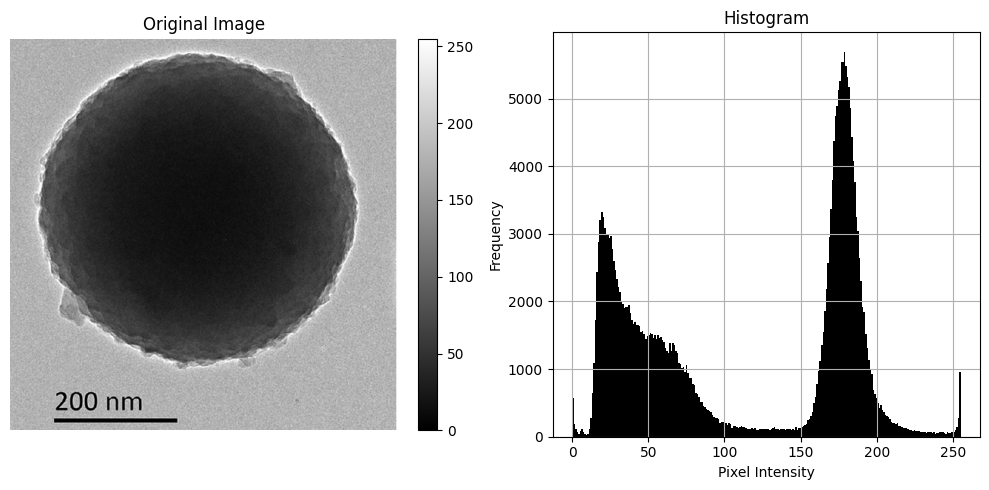

In [2]:
from src.preprocess_module import ImagePreprocessor

# Path to the image
# Image was taken from Kaggle: 
# https://www.kaggle.com/datasets/batuhanyil/electron-microscopy-particle-segmentation/
image_path = os.path.join(repo_root, 'Sample_images', '2fb8fe344c.png')
print(f'Image path: {image_path}')

# Initialize the image preprocessor and load the image as a grayscale image
preprocessor = ImagePreprocessor(image_path)

# Load and show the image
image = preprocessor.image
print(f'Size of the original image: {image.shape}')
height, width = image.shape[:2]

preprocessor.show_image(title='Original Image', show_colorbar=True, show_histogram=True)


### Histogram equalization

Histogram equalization redistributes intensity values to improve global contrast. This can make faint structures more detectable by expanding infrequently used intensity ranges.

Size of the equalized image: (517, 512)


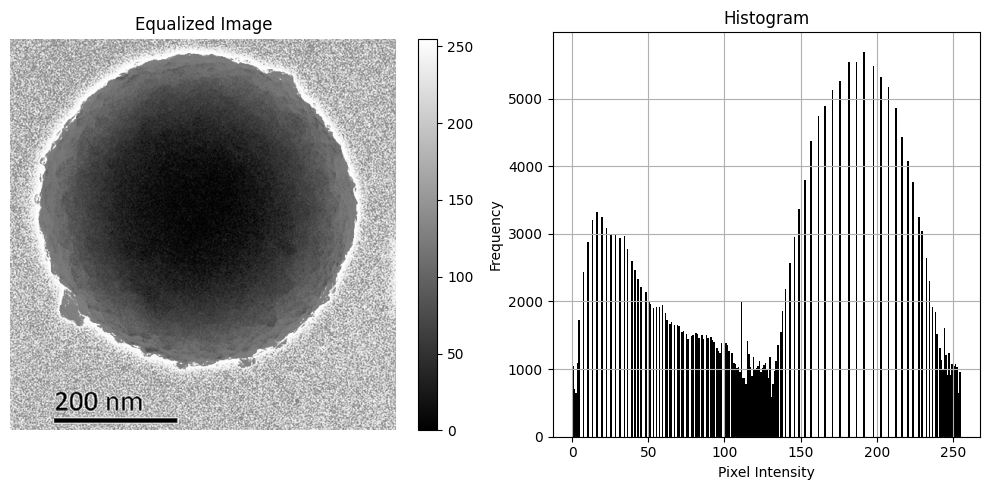

In [3]:
preprocessor.equalize_histogram()
image = preprocessor.image

print(f'Size of the equalized image: {image.shape}')
preprocessor.show_image(title='Equalized Image', show_colorbar=True, show_histogram=True)

### Standardization

Rescaling pixel values to have zero mean and unit variance reduces dataset-level intensity bias and improves convergence properties for many statistical and machine learning estimators.

Size of the standardized image: (517, 512)


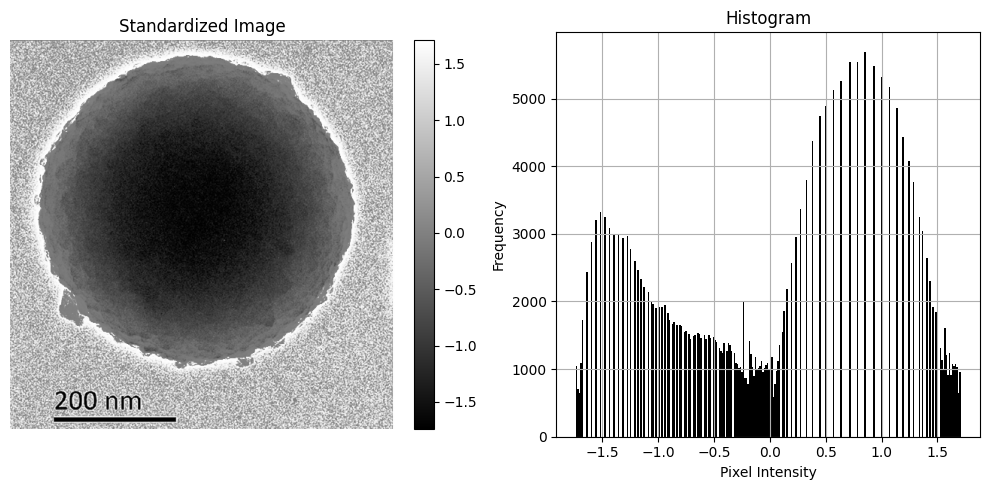

In [4]:
preprocessor.standardize()
image = preprocessor.image

print(f'Size of the standardized image: {image.shape}')
preprocessor.show_image(title='Standardized Image', show_colorbar=True, show_histogram=True)

### Image resizing

Adjusting spatial sampling aligns images to a common scale for analysis. Resizing changes the apparent size of features and must balance interpolation artefacts against model input requirements.

Size of the resized image: (1034, 1024)


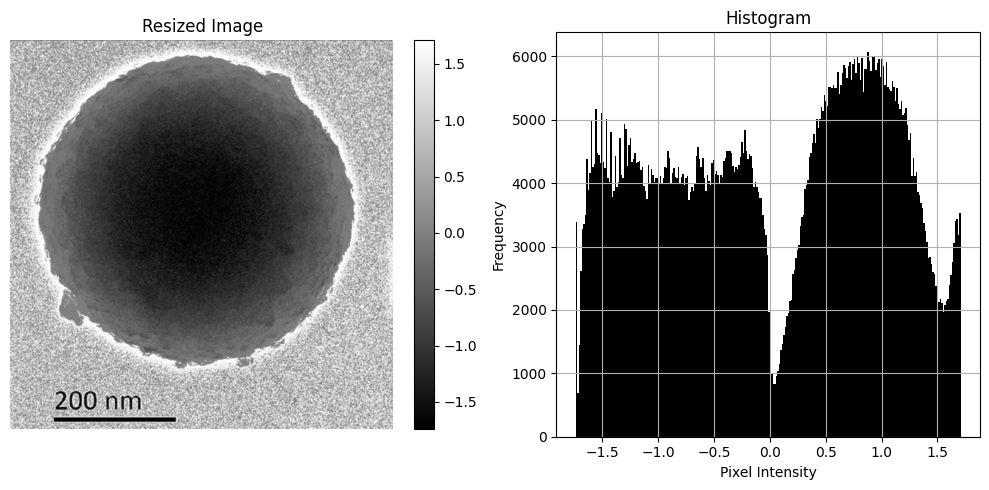

In [5]:
width_resize_factor = 2
height_resize_factor = 2
width = int(width * width_resize_factor)
height = int(height * height_resize_factor)

preprocessor.resize(width=width, height=height)
image = preprocessor.image

print(f'Size of the resized image: {image.shape}')
preprocessor.show_image(title='Resized Image', show_colorbar=True, show_histogram=True)

### Downsampling

Reducing resolution can suppress high-frequency noise and reduce computational cost; it also modifies the smallest detectable feature size and should be chosen with the analysis scale in mind.

Size of the downsampled image: (517, 512)


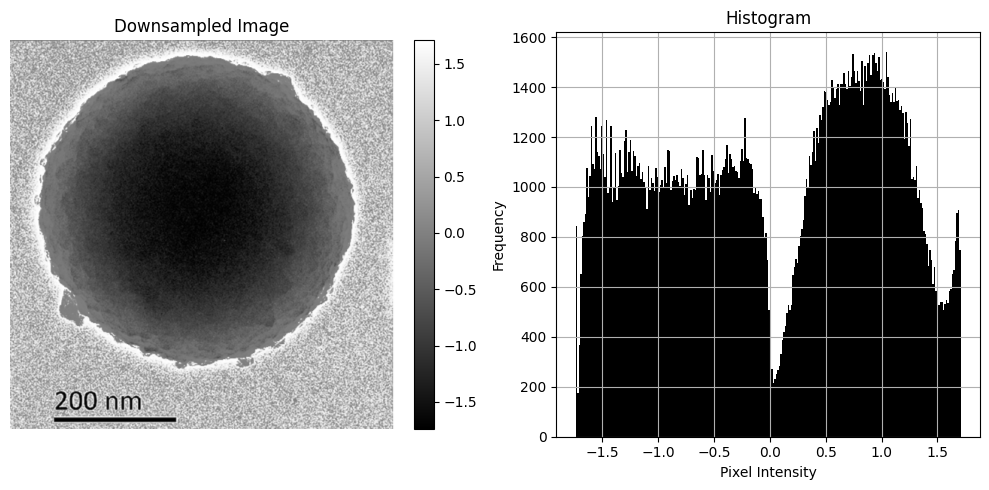

In [6]:
preprocessor.downsample(factor=2)
image = preprocessor.image

print(f'Size of the downsampled image: {image.shape}')
preprocessor.show_image(title='Downsampled Image', show_colorbar=True, show_histogram=True)

### Normalization

Mapping intensities to a fixed numeric range (e.g., [0,1]) stabilizes numerical operations and makes algorithm hyperparameters more interpretable across datasets.

Size of the normalized image: (517, 512)


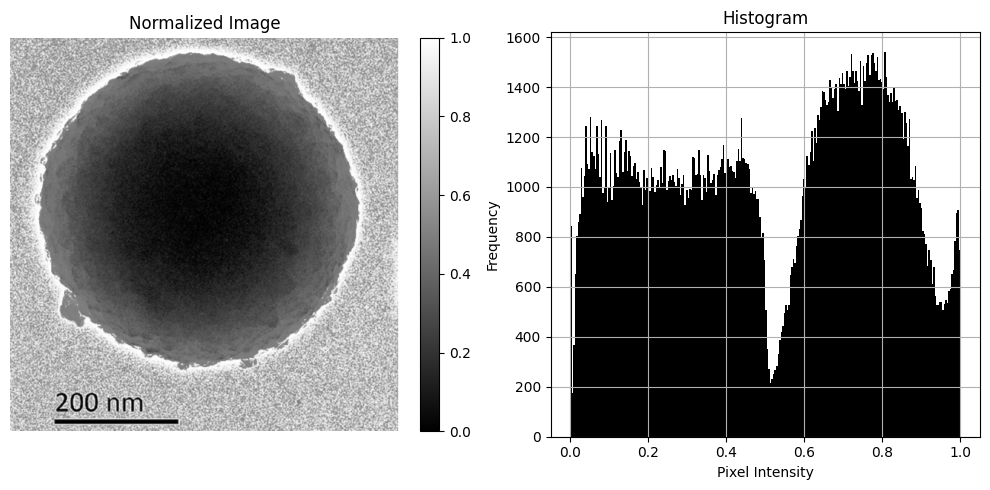

In [7]:
preprocessor.normalize()
image = preprocessor.image

print(f'Size of the normalized image: {image.shape}')
preprocessor.show_image(title='Normalized Image', show_colorbar=True, show_histogram=True)

### Gaussian smoothing

Low-pass filtering (Gaussian) reduces sensor and shot noise while preserving larger-scale structures, improving the signal-to-noise ratio for subsequent edge or segmentation analyses.

Size of the filtered image: (517, 512)


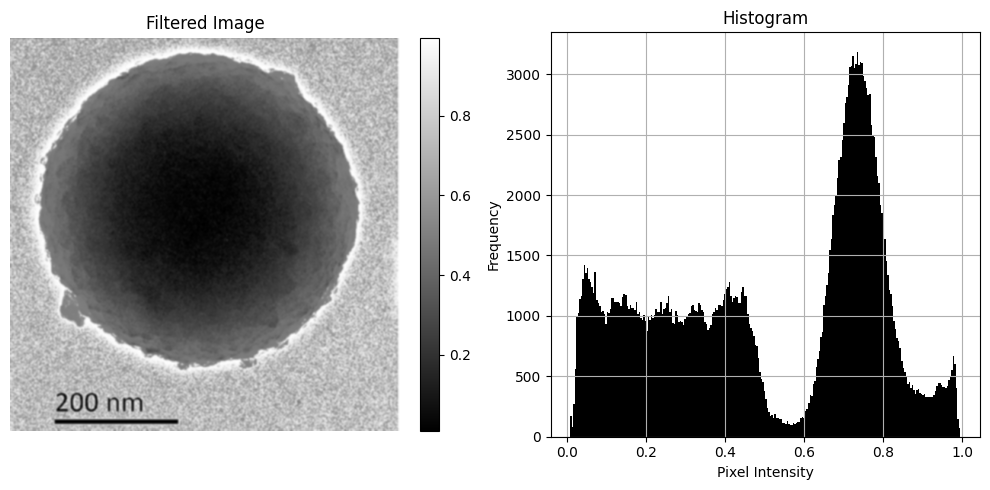

In [8]:
preprocessor.apply_filter(filter_type='gaussian', kernel_size=(5, 5))
image = preprocessor.image

print(f'Size of the filtered image: {image.shape}')
preprocessor.show_image(title='Filtered Image', show_colorbar=True, show_histogram=True)

### Edge detection

Detecting intensity gradients highlights object boundaries and structural transitions; these features are often used as priors or inputs for segmentation and morphological analysis.

Size of the edge-detected image: (517, 512)


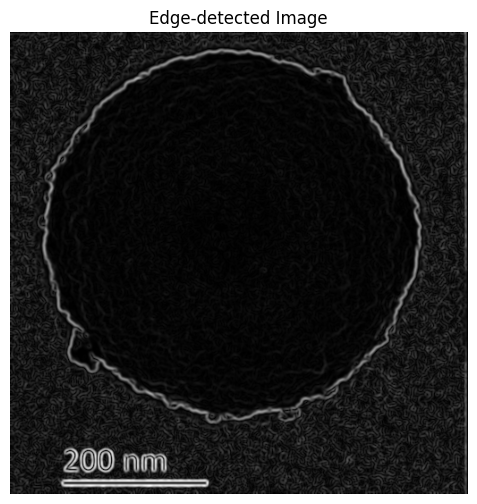

In [9]:
preprocessor.edge_detection(method='sobel')
image = preprocessor.image

print(f'Size of the edge-detected image: {image.shape}')
preprocessor.show_image(title='Edge-detected Image')

### Morphological transforms

Morphological operators probe and modify shape properties using a structuring element; they are effective at removing small artifacts and refining object boundaries for accurate measurements.

Size of the edge-detected image after morphological operations: (517, 512)


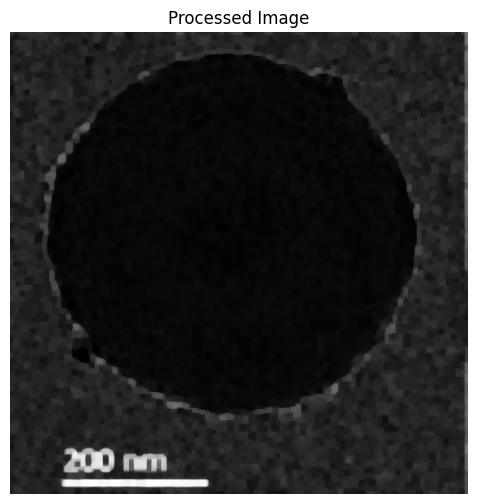

In [10]:
preprocessor.morphological_operation(operation='dilation', kernel_size=(5, 5))
preprocessor.morphological_operation(operation='erosion', kernel_size=(5, 5))
preprocessor.morphological_operation(operation='opening', kernel_size=(5, 5))
preprocessor.morphological_operation(operation='closing', kernel_size=(5, 5))
image = preprocessor.image

print(f'Size of the edge-detected image after morphological operations: {image.shape}')
preprocessor.show_image(title='Processed Image') # Note that the image is not binary yet

### Thresholding / binarization

Thresholding separates foreground from background based on intensity distributions. Choosing global, adaptive, or statistical (Otsu) thresholds depends on contrast, noise, and imaging heterogeneity.

Size of binarized image: (517, 512)


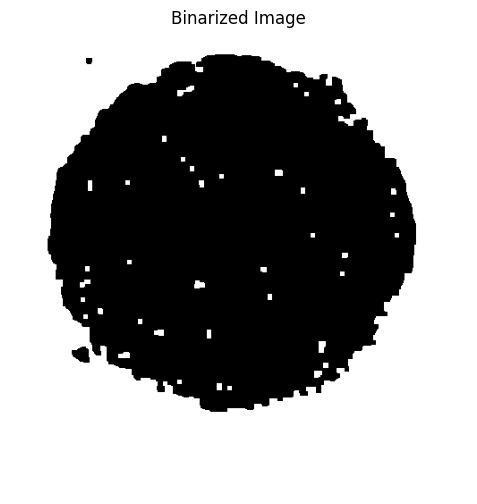

In [11]:
thresh = 0.05  # Threshold is set to 5% of the maximum intensity (arbitrarily!)
preprocessor.binarize(threshold=thresh)
image = preprocessor.image

print(f'Size of binarized image: {image.shape}')
preprocessor.show_image(title='Binarized Image')

### Morphology on binary images

Applying opening and closing on binary masks removes small spurious objects and fuses nearby regions, producing cleaner segmentation masks for accurate counting and measurements.

Size of the image after morphological operations: (517, 512)


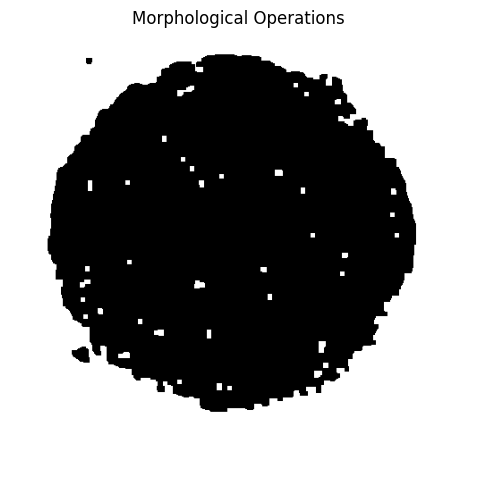

In [12]:
preprocessor.morphological_operation(operation='dilation', kernel_size=(5, 5))
preprocessor.morphological_operation(operation='erosion', kernel_size=(5, 5))
preprocessor.morphological_operation(operation='opening', kernel_size=(5, 5))
preprocessor.morphological_operation(operation='closing', kernel_size=(5, 5))

image = preprocessor.image

print(f'Size of the image after morphological operations: {image.shape}')
preprocessor.show_image(title='Morphological Operations')

### Connected-component labelling

Label connected components to enumerate discrete objects and extract per-object features (area, centroid). This is fundamental for object counting, size distribution analysis, and preparing training labels for ML models.

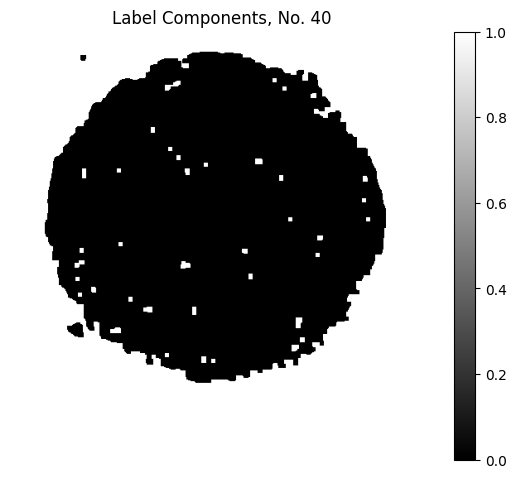

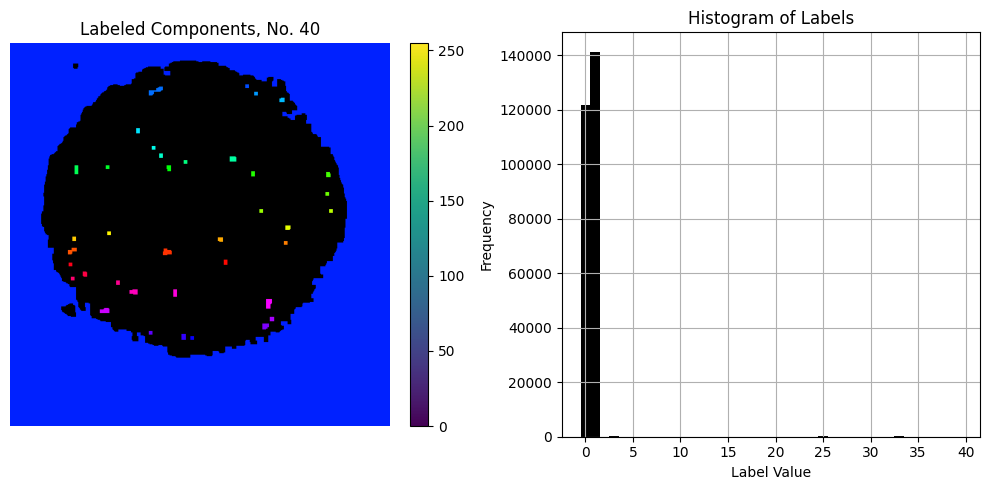

In [13]:
num_labels, labels, stats, centroids = preprocessor.label_components(connectivity=8)

preprocessor.show_image(title=f'Label Components, No. {num_labels}', show_colorbar=True)
preprocessor.show_labels(labels=labels, title=f'Labeled Components, No. {num_labels}', show_colorbar=True, show_histogram=True)